In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('data/health_v1.csv')
df.head()

,ID;Weight;Smoking;Exercise;Cholesterol;Income;Happiness;BirthYear;Sex
1;75;0;3;5,8;3230;59;1964;1
2;70;0;6;5,9;1420;43;1952;1
3;76;0;6;6;4930;74;1951;1,NaN
4;62;0;8;4,7;2970;58;1959;1
5;44;0;8;4,3;4780;64;1925;1


Initial loading attempt fails as the file is not in correct format; Common errors in data preprocessing.

It is required to handle these errors before proceeding.

One problem can be fixed immediately by adding a sep parameter as all the values go into first column due to values being separated by semicolons, not commas.

In [4]:
df = pd.read_csv('data/health_v1.csv', sep=';', na_values='NaN')
df.head()

,ID,Weight,Smoking,Exercise,Cholesterol,Income,Happiness,BirthYear,Sex
0,1,75.0,0.0,3,"5,8",3230,59.0,1964,1
1,2,70.0,0.0,6,"5,9",1420,43.0,1952,1
2,3,76.0,0.0,6,6,4930,74.0,1951,1
3,4,62.0,0.0,8,"4,7",2970,58.0,1959,1
4,5,44.0,0.0,8,"4,3",4780,64.0,1925,1


While things look better, the values in Cholesterol column raise some suspicion. The decimal separator is a comma, which is not the default for pandas. This can be fixed as well:

In [6]:
df = pd.read_csv('data/health_v1.csv', sep=';', na_values='NaN', decimal=',')
df.head()

,ID,Weight,Smoking,Exercise,Cholesterol,Income,Happiness,BirthYear,Sex
0,1,75.0,0.0,3,5.8,3230,59.0,1964,1
1,2,70.0,0.0,6,5.9,1420,43.0,1952,1
2,3,76.0,0.0,6,6.0,4930,74.0,1951,1
3,4,62.0,0.0,8,4.7,2970,58.0,1959,1
4,5,44.0,0.0,8,4.3,4780,64.0,1925,1


While things look much better now, there are still some suspicion about the data types.

In the original dataset, both the **Weight** and **Exercise** fields seemed to have integer values, but now the former seems to have been transformed into a float.

You can check the datatypes of the columns with the dtypes attribute:

In [7]:
df.dtypes

ID               int64
Weight         float64
Smoking        float64
Exercise           str
Cholesterol    float64
Income             str
Happiness      float64
BirthYear          str
Sex                str
dtype: object

In [8]:
df.Exercise.unique()

<ArrowStringArray>
['3', '6', '8', '7', '5', '4', '2', '9', '10', '0', '1', ' ']
Length: 12, dtype: str

**unique()** method reveals that there is an extra value, a space, in the Exercise column.

You can fix this by adding the **na_values** parameter to the **read_csv** function.

In [10]:
df = pd.read_csv('data/health_v1.csv', sep=';', na_values=['', ' '], decimal=',')
df.Exercise.unique()

array([ 3.,  6.,  8.,  7.,  5.,  4.,  2.,  9., 10.,  0.,  1., nan])

In [11]:
df.dtypes

ID               int64
Weight         float64
Smoking        float64
Exercise       float64
Cholesterol    float64
Income         float64
Happiness      float64
BirthYear      float64
Sex                str
dtype: object

Now the issue is mostly fixed except for the **Sex** variable as it's still a String. You can convert it to a category:

In [12]:
df['Sex'] = pd.Categorical(df['Sex'])

And check the unique values once more:

In [13]:
df.Sex.unique()

['1', '2', 'Male', 'Female']
Categories (4, str): ['1', '2', 'Female', 'Male']

There appears to be four different values:
- 1,
- 2,
- Male,
- Female.

The Sex column has initially been encoded so that **1** represents male and **2** represents female.

The written values **Male** and **Female** are most likely errors in the dataset, so you could replace them with missing values.

In [14]:
df['Sex'] = df['Sex'].astype(str)
df['Sex'] = df['Sex'].replace({'Male': '1', 'Female': '2'})
df['Sex'] = df['Sex'].astype('category')

In [15]:
df.describe(include='all')

,ID,Weight,Smoking,Exercise,Cholesterol,Income,Happiness,BirthYear,Sex
count,1000.000000,999.000000,999.000000,998.000000,1000.00000,997.000000,999.000000,999.000000,1000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,523
mean,500.500000,79.717718,0.232232,5.092184,5.72750,3069.829488,51.171171,1954.111111,NaN
std,288.819436,25.252719,0.422468,2.030736,1.39649,1264.497563,17.511569,21.443328,NaN
min,1.000000,8.000000,0.000000,0.000000,-7.50000,0.000000,0.000000,1879.000000,NaN
25%,250.750000,70.000000,0.000000,4.000000,4.87500,2220.000000,39.000000,1939.000000,NaN
50%,500.500000,80.000000,0.000000,5.000000,5.80000,3140.000000,50.000000,1954.000000,NaN
75%,750.250000,88.000000,0.000000,6.000000,6.60000,3890.000000,63.000000,1969.000000,NaN


#### Treating missing values and outliers

Missing values can be handled in several different ways:
- Ignoring them,
- Removing rows with missing values,
- Removing columns with missing values,
- Imputing missing values with the mean, median or mode of the column.
- Using ML algorithms to predict missing values,,
- Using domain knowledge to fill in missing values. This means that human expert fills the missing values based on their knowledge of the data but this approach is highly dangerous as it may introduce bias into the data.

#### Filtering and visualizing data

In [16]:
df.describe()

,ID,Weight,Smoking,Exercise,Cholesterol,Income,Happiness,BirthYear
count,1000.000000,999.000000,999.000000,998.000000,1000.00000,997.000000,999.000000,999.000000
mean,500.500000,79.717718,0.232232,5.092184,5.72750,3069.829488,51.171171,1954.111111
std,288.819436,25.252719,0.422468,2.030736,1.39649,1264.497563,17.511569,21.443328
min,1.000000,8.000000,0.000000,0.000000,-7.50000,0.000000,0.000000,1879.000000
25%,250.750000,70.000000,0.000000,4.000000,4.87500,2220.000000,39.000000,1939.000000
50%,500.500000,80.000000,0.000000,5.000000,5.80000,3140.000000,50.000000,1954.000000
75%,750.250000,88.000000,0.000000,6.000000,6.60000,3890.000000,63.000000,1969.000000
max,1000.000000,740.000000,1.000000,10.000000,9.50000,7690.000000,100.000000,2020.000000


- Minimum value of the Weight column is 8kg and max value is 740kg. These values are almost certainly errors.

- Some values in the Cholesterol column are negative, which is impossible.

- The values in the BirthYear column vary between 1879 and 2020, possible that the min value is an error as the subjects should be adults at the time of the survey (2024), the max value is suspicious.

In [17]:

import matplotlib.pyplot as plt

def plot_data(df):
    plt.figure(figsize=(20, 10))
    for i, col in enumerate(df.select_dtypes(include=['int', 'float'])):
        plt.subplot(3, 3, i + 1)
        df[col].plot(kind='hist', title=col)
        plt.xlabel(col)

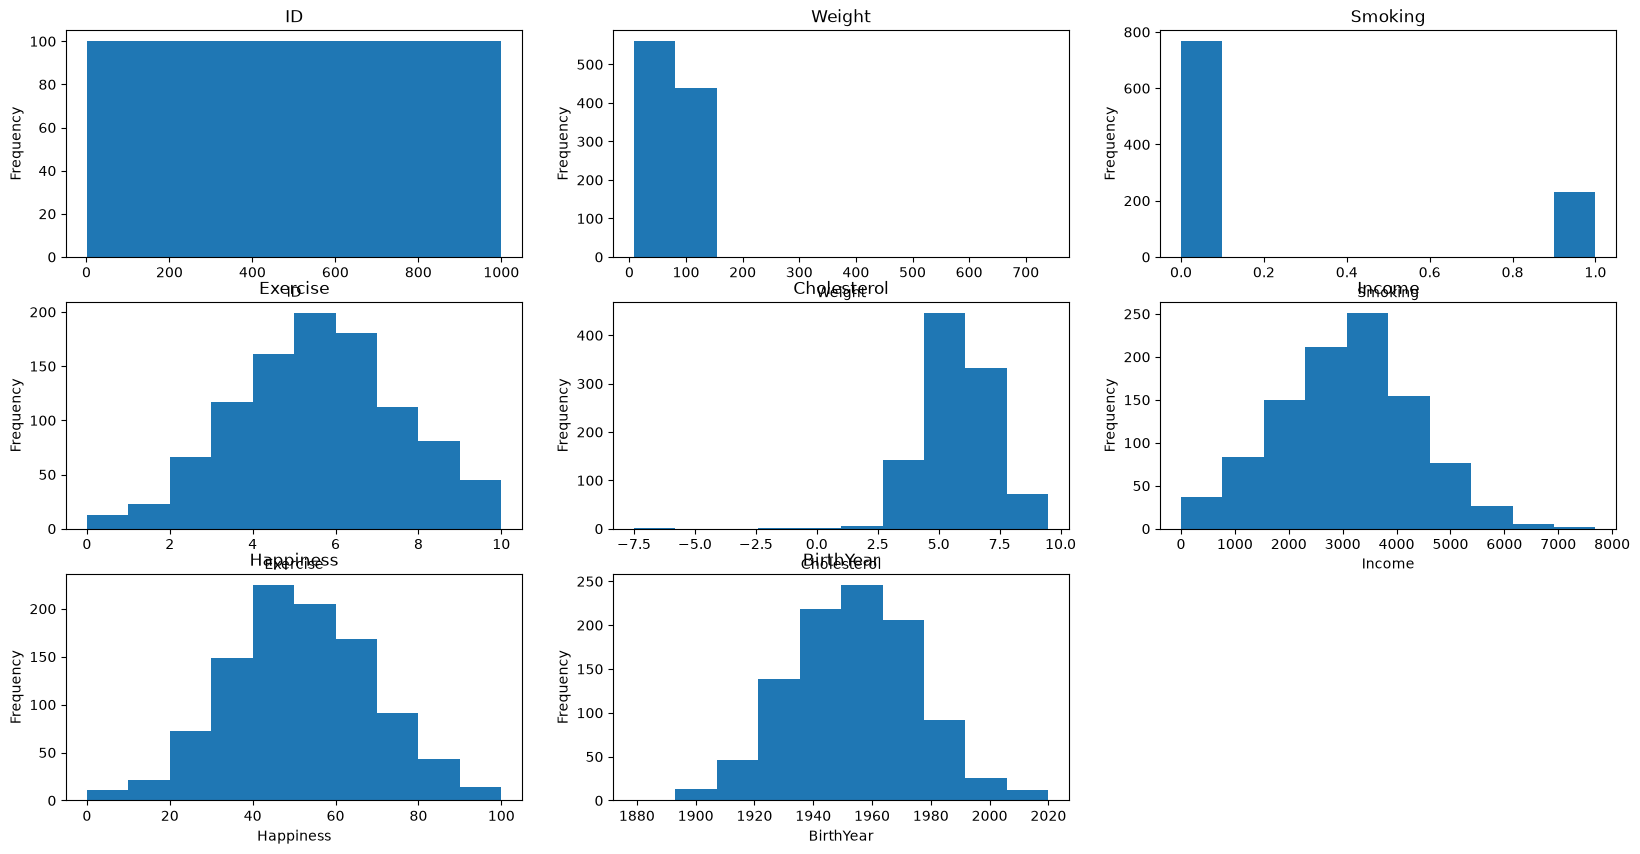

In [18]:
plot_data(df)

#### Filtering rows

Start the data cleansing by selecting rows that correspond individuals whose age was between 18 and 99 years at the time of the survey. This can be done by filtering the BirthYear column

In [20]:
df = df[(df['BirthYear'] <= 2006) & (df['BirthYear'] >= 1925)]
df.describe(include='all')

,ID,Weight,Smoking,Exercise,Cholesterol,Income,Happiness,BirthYear,Sex
count,916.000000,915.000000,915.000000,914.000000,916.000000,913.000000,915.000000,916.000000,916
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,479
mean,499.403930,80.018579,0.231694,5.086433,5.697380,3055.147864,51.398907,1956.545852,NaN
std,287.480346,26.016589,0.422145,2.028864,1.299682,1252.155512,17.507904,17.987278,NaN
min,1.000000,8.000000,0.000000,0.000000,-1.900000,0.000000,0.000000,1925.000000,NaN
25%,253.500000,70.000000,0.000000,4.000000,4.800000,2220.000000,40.000000,1942.000000,NaN
50%,502.500000,80.000000,0.000000,5.000000,5.700000,3110.000000,51.000000,1956.000000,NaN
75%,746.250000,88.000000,0.000000,6.000000,6.600000,3890.000000,63.000000,1970.000000,NaN


#### Filtering columns

As some weight values looked suspicious, we filter the data by making sure all the weight are between 30kg and 200kg. Values outside this range are replaced with missing values. 

Similarly, you can filter the Cholesterol column by removing all the values smaller than 2.0 mmol/l.

In [23]:
df['Weight'] = df['Weight'].apply(lambda x: x if 30 <= x <= 200 else None)
df['Cholesterol'] = df['Cholesterol'].apply(lambda x: x if x >= 2.0 else None)

df

,ID,Weight,Smoking,Exercise,Cholesterol,Income,Happiness,BirthYear,Sex
0,1,75.0,0.0,3.0,5.8,3230.0,59.0,1964.0,1
1,2,70.0,0.0,6.0,5.9,1420.0,43.0,1952.0,1
2,3,76.0,0.0,6.0,6.0,4930.0,74.0,1951.0,1
3,4,62.0,0.0,8.0,4.7,2970.0,58.0,1959.0,1
4,5,44.0,0.0,8.0,4.3,4780.0,64.0,1925.0,1
...,...,...,...,...,...,...,...,...,...
994,995,76.0,0.0,10.0,4.1,2900.0,61.0,1960.0,2
996,997,77.0,1.0,4.0,6.6,2990.0,45.0,1971.0,2
997,998,71.0,0.0,8.0,4.5,4840.0,74.0,1935.0,2
998,999,107.0,1.0,2.0,8.4,2030.0,38.0,1929.0,2


We can re-plot the histograms with the previously-written function to see if the filtering has had the desired effect:

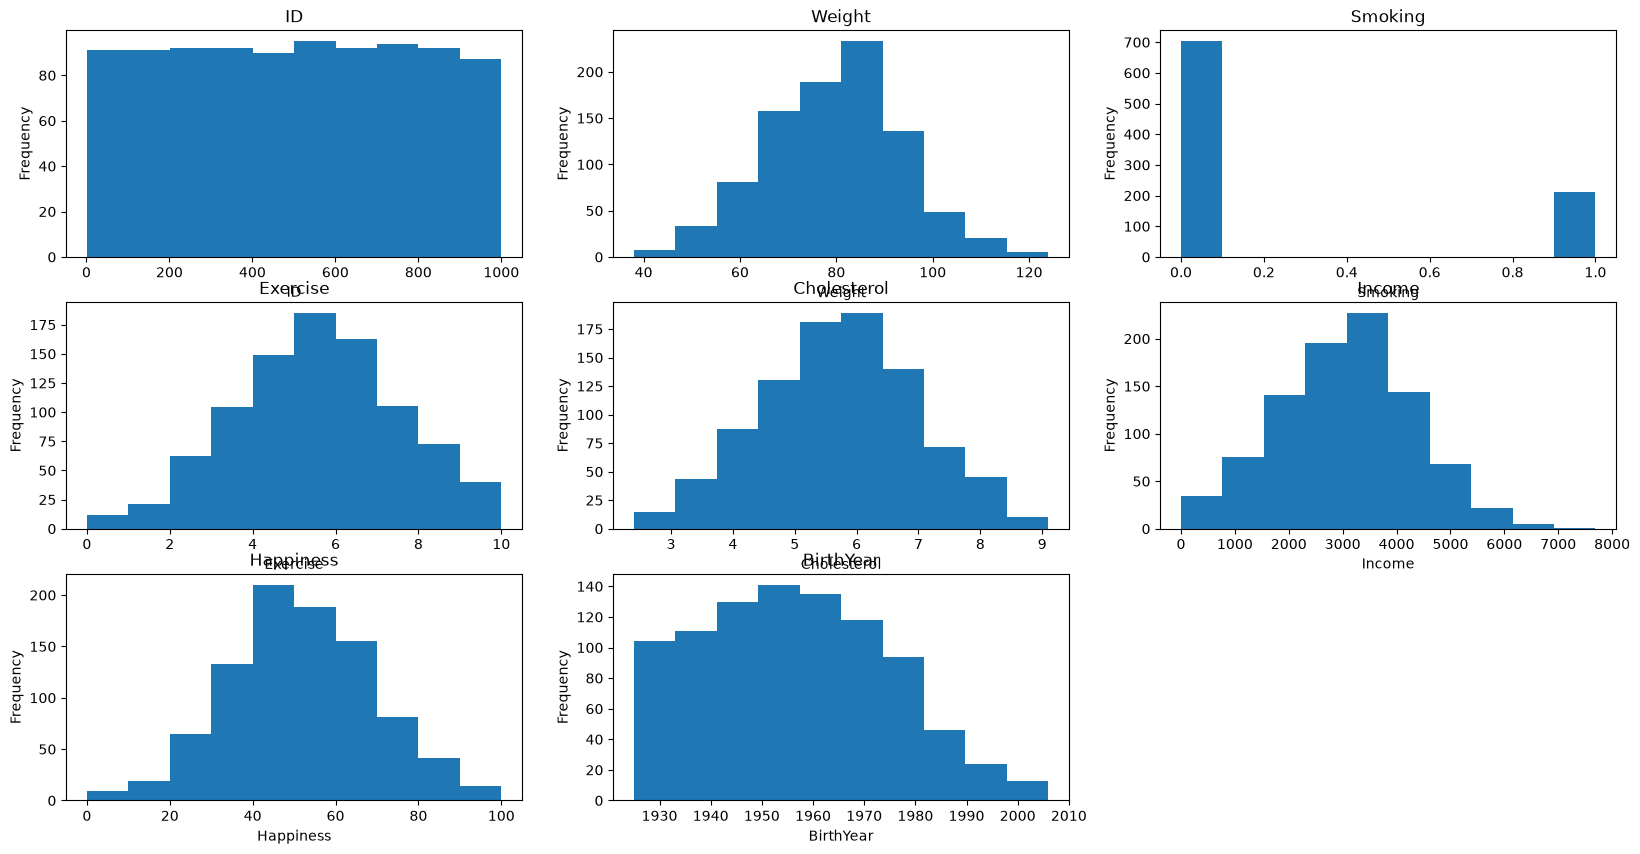

In [24]:
plot_data(df)

#### Adding a new variable

In the existing dataset, there's a fixed set of variables. 

Say, you want to divide the persons into 2 group; **A** and **B**, at random.

This can be done by adding a new variable **Group** to the dataset. New columns can be added to a dataframe by simple assigning values to them:

In [ ]:
np.random.seed(42) # Seed for NumPy's random-number generator.
df['Group'] = np.random.choice(['A', 'B'], size=len(df))
df

# Explanation for number 42
#"Start the random-number generator from this particular starting point."
# So every time you run the code with seed 42, you get the same sequence of 'random' choices. 

,ID,Weight,Smoking,Exercise,Cholesterol,Income,Happiness,BirthYear,Sex,Group
0,1,75.0,0.0,3.0,5.8,3230.0,59.0,1964.0,1,A
1,2,70.0,0.0,6.0,5.9,1420.0,43.0,1952.0,1,B
2,3,76.0,0.0,6.0,6.0,4930.0,74.0,1951.0,1,A
3,4,62.0,0.0,8.0,4.7,2970.0,58.0,1959.0,1,A
4,5,44.0,0.0,8.0,4.3,4780.0,64.0,1925.0,1,A
...,...,...,...,...,...,...,...,...,...,...
994,995,76.0,0.0,10.0,4.1,2900.0,61.0,1960.0,2,A
996,997,77.0,1.0,4.0,6.6,2990.0,45.0,1971.0,2,A
997,998,71.0,0.0,8.0,4.5,4840.0,74.0,1935.0,2,B
998,999,107.0,1.0,2.0,8.4,2030.0,38.0,1929.0,2,B


#### Renaming variables

Renaming a variable is a common task. 
You can rename the **Smoking** variable to **Smoker** as shown below:

The parameter **inplace=True** modifies the dataframe in place, without creating a new dataframe.

If **inplace=False**, a new dataframe is created, and the original dataframe is not modified. The columns to be renamed are specified in a dictionary, where the keys are the old column names, and the values are the new column names.

In [27]:
df.rename(columns={'Smoking': 'Smoker'}, inplace=True)
df

,ID,Weight,Smoker,Exercise,Cholesterol,Income,Happiness,BirthYear,Sex,Group
0,1,75.0,0.0,3.0,5.8,3230.0,59.0,1964.0,1,A
1,2,70.0,0.0,6.0,5.9,1420.0,43.0,1952.0,1,B
2,3,76.0,0.0,6.0,6.0,4930.0,74.0,1951.0,1,A
3,4,62.0,0.0,8.0,4.7,2970.0,58.0,1959.0,1,A
4,5,44.0,0.0,8.0,4.3,4780.0,64.0,1925.0,1,A
...,...,...,...,...,...,...,...,...,...,...
994,995,76.0,0.0,10.0,4.1,2900.0,61.0,1960.0,2,A
996,997,77.0,1.0,4.0,6.6,2990.0,45.0,1971.0,2,A
997,998,71.0,0.0,8.0,4.5,4840.0,74.0,1935.0,2,B
998,999,107.0,1.0,2.0,8.4,2030.0,38.0,1929.0,2,B


#### Merging data frames

In [28]:
# construct data set with ID and blood glucose values for some individuals
data = {'ID': [1, 3, 5, 7, 9],
        'Glucose': [5.2, 6.1, 5.8, 6.5, 5.9]}
df2 = pd.DataFrame(data)
df2

,ID,Glucose
0,1,5.2
1,3,6.1
2,5,5.8
3,7,6.5
4,9,5.9


Now proceed with the merging.

Combine the values of **df2** into **df** based on the ID variable:

In [29]:
df = pd.merge(df, df2, on='ID', how='left')
df

,ID,Weight,Smoker,Exercise,Cholesterol,Income,Happiness,BirthYear,Sex,Group,Glucose
0,1,75.0,0.0,3.0,5.8,3230.0,59.0,1964.0,1,A,5.2
1,2,70.0,0.0,6.0,5.9,1420.0,43.0,1952.0,1,B,NaN
2,3,76.0,0.0,6.0,6.0,4930.0,74.0,1951.0,1,A,6.1
3,4,62.0,0.0,8.0,4.7,2970.0,58.0,1959.0,1,A,NaN
4,5,44.0,0.0,8.0,4.3,4780.0,64.0,1925.0,1,A,5.8
...,...,...,...,...,...,...,...,...,...,...,...
911,995,76.0,0.0,10.0,4.1,2900.0,61.0,1960.0,2,A,NaN
912,997,77.0,1.0,4.0,6.6,2990.0,45.0,1971.0,2,A,NaN
913,998,71.0,0.0,8.0,4.5,4840.0,74.0,1935.0,2,B,NaN
914,999,107.0,1.0,2.0,8.4,2030.0,38.0,1929.0,2,B,NaN


Note that all the remaining values in the Glucose column are automatically encoded as missing.

This is due to merge operation is a left join, which means that all the values in the left data frame (df) are retained and the missing values are filled with **NaN**.

You might notice resemblance of the **merge** functions to the SQL **JOIN** operation.

#### Dropping variables

Next, we drop the newly-created Group variable from the data frame.

In [30]:
df.drop(columns=['Group'], inplace=True)
df

,ID,Weight,Smoker,Exercise,Cholesterol,Income,Happiness,BirthYear,Sex,Glucose
0,1,75.0,0.0,3.0,5.8,3230.0,59.0,1964.0,1,5.2
1,2,70.0,0.0,6.0,5.9,1420.0,43.0,1952.0,1,NaN
2,3,76.0,0.0,6.0,6.0,4930.0,74.0,1951.0,1,6.1
3,4,62.0,0.0,8.0,4.7,2970.0,58.0,1959.0,1,NaN
4,5,44.0,0.0,8.0,4.3,4780.0,64.0,1925.0,1,5.8
...,...,...,...,...,...,...,...,...,...,...
911,995,76.0,0.0,10.0,4.1,2900.0,61.0,1960.0,2,NaN
912,997,77.0,1.0,4.0,6.6,2990.0,45.0,1971.0,2,NaN
913,998,71.0,0.0,8.0,4.5,4840.0,74.0,1935.0,2,NaN
914,999,107.0,1.0,2.0,8.4,2030.0,38.0,1929.0,2,NaN


#### Plotting a correlation matrix

Create a correlation matrix that displays the relationships between pairs of variables in the dataset. 

**corr()** method is used which calculates the Pearson correlation coefficient between pairs of variables.

ID variable is dropped as it does not make sense to include a unique identifier for each individual.

In [31]:
corr = df.drop(columns=['ID']).corr()
corr

,Weight,Smoker,Exercise,Cholesterol,Income,Happiness,BirthYear,Sex,Glucose
Weight,1.000000,0.503787,-0.705655,0.610943,-0.297884,-0.510337,0.044415,0.221453,0.314887
Smoker,0.503787,1.000000,-0.472535,0.440167,-0.245318,-0.347556,-0.015956,0.093259,NaN
Exercise,-0.705655,-0.472535,1.000000,-0.670084,0.325179,0.581063,-0.037096,0.042373,0.787909
Cholesterol,0.610943,0.440167,-0.670084,1.000000,-0.294709,-0.588609,-0.204828,-0.008608,-0.656034
Income,-0.297884,-0.245318,0.325179,-0.294709,1.000000,0.526107,-0.018189,0.019903,0.231841
Happiness,-0.510337,-0.347556,0.581063,-0.588609,0.526107,1.000000,0.079088,0.011014,0.809450
BirthYear,0.044415,-0.015956,-0.037096,-0.204828,-0.018189,0.079088,1.000000,-0.045901,0.362514
Sex,0.221453,0.093259,0.042373,-0.008608,0.019903,0.011014,-0.045901,1.000000,0.707107
Glucose,0.314887,NaN,0.787909,-0.656034,0.231841,0.809450,0.362514,0.707107,1.000000


For each pair of variables in the dataset, the correlation matrix shows the strength and direction of the relationship between the variables. 

The correlation coefficient ranges from -1 to 1 where -1 indicates a perfect negative relationship, 1 indicates a perfect positive relationship and 0 indicates no relationship.

We can visualize the correlation matrix with a heatmap:

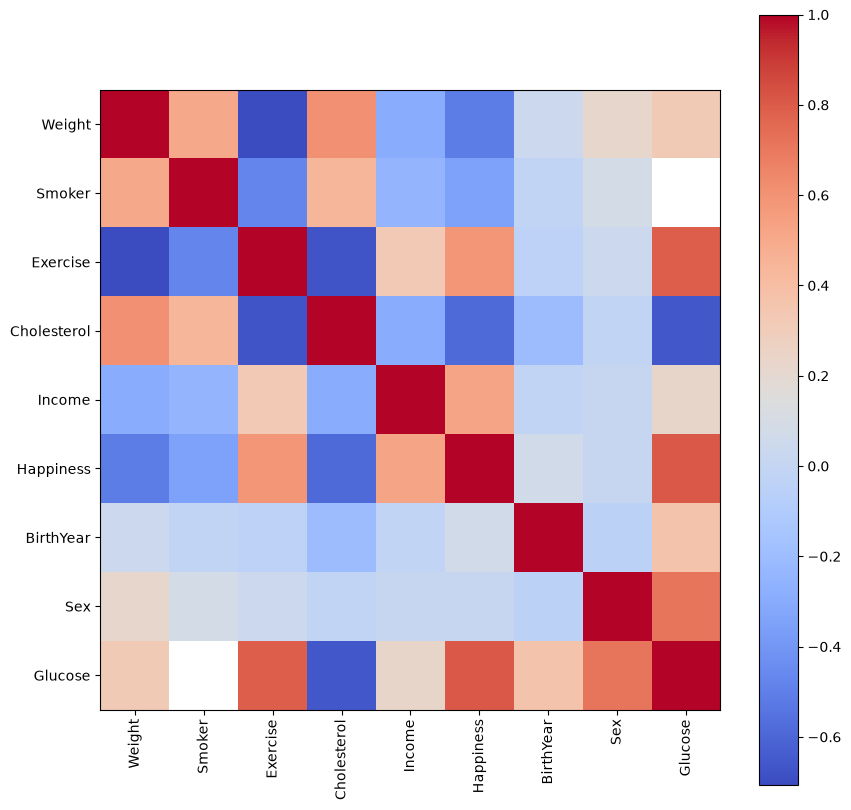

In [32]:

# create heatmap with Matplotlib

plt.figure(figsize=(10, 10))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.show()

#### Cumulative distribution function

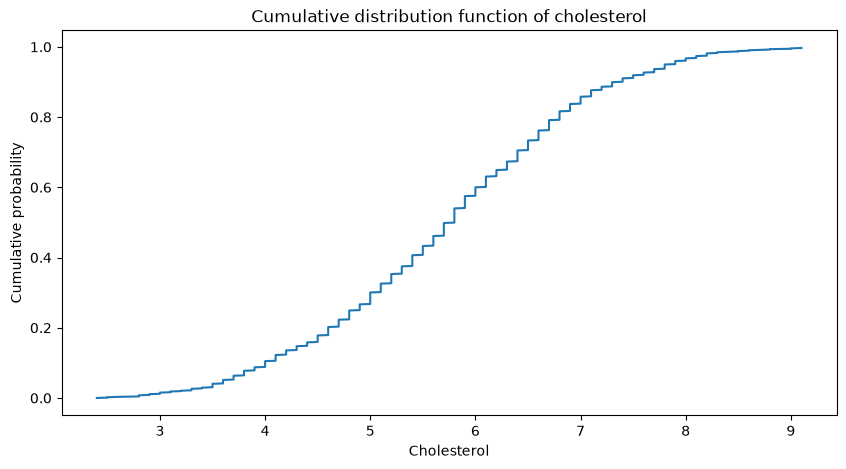

In [33]:
# sort the values in the Cholesterol column
sorted_data = df['Cholesterol'].sort_values()

# create a list of evenly spaced values between 0 and 1
cumulative = np.linspace(0, 1, len(sorted_data))

# create the plot
plt.figure(figsize=(10, 5))
plt.plot(sorted_data, cumulative)
plt.xlabel('Cholesterol')
plt.ylabel('Cumulative probability')
plt.title('Cumulative distribution function of cholesterol')
plt.show()